# 05 · Inverse Design — Recover Doping from I–V

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/05_inverse_design.ipynb)

Given a measured I–V, recover the doping by gradient descent through the differentiable surrogate. Because the surrogate is differentiable in the doping encoding, backprop flows straight to the doping level.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.11.0+cu128


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)

from bayespinn_inv.surrogate import (SymlogTransform, Normalizer, IVSurrogate,
    IVSurrogateConfig, build_sg_dataset, train_surrogate)
symlog = SymlogTransform(I0=1e-6)
biases = np.linspace(0.0, 0.6, 13)
profiles = [step(L) for L in np.geomspace(5e20, 5e22, 11)]
X, Y = build_sg_dataset(profiles, biases, scaling, sg, symlog)
norm = Normalizer.fit(X)
net = IVSurrogate(IVSurrogateConfig(doping_dim=N_ANCHOR, hidden=128, n_layers=3, seed=0))
train_surrogate(net, X, Y, norm, epochs=2500, lr=2e-3)


[54.958274841308594,
 53.967445373535156,
 52.90961837768555,
 51.644710540771484,
 50.05556106567383,
 48.04423141479492,
 45.52885437011719,
 42.45137023925781,
 38.79275131225586,
 34.60052490234375,
 30.033906936645508,
 25.428457260131836,
 21.382108688354492,
 18.80225944519043,
 18.534774780273438,
 19.773223876953125,
 19.878402709960938,
 18.1955623626709,
 15.682537078857422,
 13.309222221374512,
 11.553631782531738,
 10.43399429321289,
 9.724037170410156,
 9.163054466247559,
 8.568737983703613,
 7.855270862579346,
 7.00355863571167,
 6.030332565307617,
 4.986203670501709,
 3.971605062484741,
 3.1276259422302246,
 2.5564379692077637,
 2.2410550117492676,
 2.127483367919922,
 2.125030994415283,
 2.056337594985962,
 1.8117308616638184,
 1.4548943042755127,
 1.1141670942306519,
 0.872453510761261,
 0.7721169590950012,
 0.8093181252479553,
 0.9088337421417236,
 0.9706944823265076,
 0.9449548125267029,
 0.8491218686103821,
 0.7376830577850342,
 0.6650750637054443,
 0.6576226949691

## Recover a held-out doping level
Target I–V from SG at an unseen level; optimize $\log_{10}N$ to match.

C:\Users\abhis\AppData\Local\Temp\ipykernel_30208\515064269.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  loss.backward(); opt.step(); logL.data.clamp_(20,23); traj.append(float(logL))


true log10(N)=21.778, recovered=21.783, error=0.005 decades


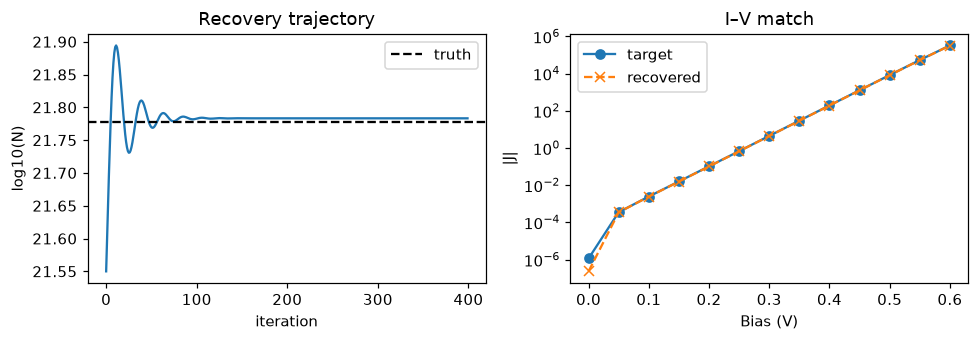

In [3]:

half = N_ANCHOR//2
def encode_level(logL):
    C = torch.cat([-(10.0**logL).repeat(half), (10.0**logL).repeat(N_ANCHOR-half)])
    return scaling.doping_to_net_input(C)

true_L = 6e21
target = torch.tensor(symlog.forward(sg_iv(step(true_L), biases)), dtype=torch.float32)
bs = torch.tensor(biases/VT, dtype=torch.float32)
logL = torch.tensor(21.5, requires_grad=True)
opt = torch.optim.Adam([logL], lr=0.05)
traj=[]
for it in range(400):
    opt.zero_grad()
    lat = encode_level(logL)
    feats = torch.stack([torch.cat([lat, bs[i].reshape(1)]) for i in range(len(biases))])
    pred = net((feats-norm.mean)/norm.std).reshape(-1)
    loss = torch.nn.functional.mse_loss(pred, target)
    loss.backward(); opt.step(); logL.data.clamp_(20,23); traj.append(float(logL))
print(f"true log10(N)={np.log10(true_L):.3f}, recovered={float(logL):.3f}, "
      f"error={abs(float(logL)-np.log10(true_L)):.3f} decades")

fig, ax = plt.subplots(1,2, figsize=(9,3.2))
ax[0].plot(traj); ax[0].axhline(np.log10(true_L), ls="--", c="k", label="truth")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("log10(N)"); ax[0].set_title("Recovery trajectory"); ax[0].legend()
Irec = sg_iv(step(10**float(logL)), biases)
Itrue = sg_iv(step(true_L), biases)
ax[1].semilogy(biases, np.abs(Itrue), "o-", label="target")
ax[1].semilogy(biases, np.abs(Irec), "x--", label="recovered")
ax[1].set_xlabel("Bias (V)"); ax[1].set_ylabel("|J|"); ax[1].set_title("I–V match"); ax[1].legend()
plt.tight_layout(); plt.show()
